# Imports

In [55]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

np.random.seed(42)
tf.random.set_seed(42)

print("Libraries loaded.")
print("TensorFlow version:", tf.__version__)

Libraries loaded.
TensorFlow version: 2.21.0


# Load Dataset

In [5]:
df = pd.read_csv("amazon_product_reviews_with_attacks.csv")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head())

Shape: (1537, 15)

Columns:
['customer_id', 'product_id', 'product_name', 'star_rating', 'helpful_votes', 'do_recommend', 'review_date', 'review_body', 'review_year', 'review_length', 'verified_purchase', 'user_review_count', 'noise_type', 'attack_label', 'item_review_count']


,customer_id,product_id,product_name,star_rating,helpful_votes,do_recommend,review_date,review_body,review_year,review_length,verified_purchase,user_review_count,noise_type,attack_label,item_review_count
0,Cristina M,B00QJDU3KY,Kindle Paperwhite,5,139,NaN,2015-08-08 00:00:00+00:00,I initially had trouble deciding between the p...,2015.0,1064,N,1,original,0,18
1,Ricky,B00QJDU3KY,Kindle Paperwhite,5,126,NaN,2015-09-01 00:00:00+00:00,Allow me to preface this with a little history...,2015.0,1424,N,1,original,0,18
2,Tedd Gardiner,B00QJDU3KY,Kindle Paperwhite,4,69,NaN,2015-07-20 00:00:00+00:00,I am enjoying it so far. Great for reading. Ha...,2015.0,182,N,1,original,0,18
3,Dougal,B00QJDU3KY,Kindle Paperwhite,5,2,NaN,2017-06-16 00:00:00+00:00,I bought one of the first Paperwhites and have...,2017.0,1671,N,1,original,0,18
4,Miljan David Tanic,B00QJDU3KY,Kindle Paperwhite,5,17,NaN,2016-08-11 00:00:00+00:00,I have to say upfront - I don't like coroporat...,2016.0,1916,N,1,original,0,18


# Standardize and select columns

In [6]:
df.columns = [c.strip().lower() for c in df.columns]

required_cols = [
    "customer_id", "product_id", "star_rating", "review_date",
    "helpful_votes", "review_length", "user_review_count",
    "item_review_count", "noise_type", "attack_label"
]

missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df = df[required_cols].dropna(subset=["customer_id", "product_id", "star_rating", "review_date"]).copy()

print("Cleaned shape:", df.shape)
display(df.head())

Cleaned shape: (1210, 10)


,customer_id,product_id,star_rating,review_date,helpful_votes,review_length,user_review_count,item_review_count,noise_type,attack_label
0,Cristina M,B00QJDU3KY,5,2015-08-08 00:00:00+00:00,139,1064,1,18,original,0
1,Ricky,B00QJDU3KY,5,2015-09-01 00:00:00+00:00,126,1424,1,18,original,0
2,Tedd Gardiner,B00QJDU3KY,4,2015-07-20 00:00:00+00:00,69,182,1,18,original,0
3,Dougal,B00QJDU3KY,5,2017-06-16 00:00:00+00:00,2,1671,1,18,original,0
4,Miljan David Tanic,B00QJDU3KY,5,2016-08-11 00:00:00+00:00,17,1916,1,18,original,0


# Convert date and encode users/items

In [7]:
df["review_date"] = pd.to_datetime(df["review_date"], errors="coerce")
df = df.dropna(subset=["review_date"]).copy()

user_encoder = LabelEncoder()
item_encoder = LabelEncoder()

df["user_idx"] = user_encoder.fit_transform(df["customer_id"])
df["item_idx"] = item_encoder.fit_transform(df["product_id"])

n_users = df["user_idx"].nunique()
n_items = df["item_idx"].nunique()

print("Users :", n_users)
print("Items :", n_items)
print("Rows  :", len(df))
print("Date range:", df["review_date"].min(), "to", df["review_date"].max())

Users : 789
Items : 53
Rows  : 1210
Date range: 2012-09-12 00:00:00+00:00 to 2017-07-31 00:00:00+00:00


# Create normalized numeric features

In [8]:
scaler = MinMaxScaler()

numeric_cols = ["star_rating", "helpful_votes", "review_length", "user_review_count", "item_review_count"]
df[numeric_cols] = df[numeric_cols].fillna(0)

df[["helpful_votes_norm", "review_length_norm", "user_review_count_norm", "item_review_count_norm"]] = scaler.fit_transform(
    df[["helpful_votes", "review_length", "user_review_count", "item_review_count"]]
)

# Normalize rating from [1,5] to [0,1]
df["rating_norm"] = (df["star_rating"] - 1.0) / 4.0

# Normalize time
min_date = df["review_date"].min()
max_date = df["review_date"].max()

df["time_norm"] = (
    (df["review_date"] - min_date).dt.total_seconds() /
    (max_date - min_date).total_seconds()
).astype(np.float32)

display(df.head())

,customer_id,product_id,star_rating,review_date,helpful_votes,review_length,user_review_count,item_review_count,noise_type,attack_label,user_idx,item_idx,helpful_votes_norm,review_length_norm,user_review_count_norm,item_review_count_norm,rating_norm,time_norm
0,Cristina M,B00QJDU3KY,5,2015-08-08 00:00:00+00:00,139,1064,1,18,original,0,115,20,0.142564,0.399774,0.0,0.025225,1.00,0.594504
1,Ricky,B00QJDU3KY,5,2015-09-01 00:00:00+00:00,126,1424,1,18,original,0,509,20,0.129231,0.535418,0.0,0.025225,1.00,0.607964
2,Tedd Gardiner,B00QJDU3KY,4,2015-07-20 00:00:00+00:00,69,182,1,18,original,0,592,20,0.070769,0.067445,0.0,0.025225,0.75,0.583847
3,Dougal,B00QJDU3KY,5,2017-06-16 00:00:00+00:00,2,1671,1,18,original,0,159,20,0.002051,0.628485,0.0,0.025225,1.00,0.974762
4,Miljan David Tanic,B00QJDU3KY,5,2016-08-11 00:00:00+00:00,17,1916,1,18,original,0,433,20,0.017436,0.720799,0.0,0.025225,1.00,0.801458


# Build feedback types

Since your dataset already has reviews with ratings, we can create the 4 feedback types like the paper style:

ep = explicit positive
en = explicit negative
ip = implicit positive
in = implicit negative

In [9]:
def assign_feedback_type(r):
    if r >= 5:
        return "ep"   # explicit positive
    elif r <= 1:
        return "en"   # explicit negative
    elif r in [3, 4]:
        return "ip"   # implicit positive
    else:
        return "in"   # implicit negative

df["feedback_type"] = df["star_rating"].apply(assign_feedback_type)

print(df["feedback_type"].value_counts())

feedback_type
ep    760
ip    388
en     32
in     30
Name: count, dtype: int64


# Target Variable

In [10]:
df["target"] = (df["star_rating"] >= 4).astype(int)

print(df["target"].value_counts())
print(df["attack_label"].value_counts())
print(df["noise_type"].value_counts())

target
1    1060
0     150
Name: count, dtype: int64
attack_label
0    850
1    360
Name: count, dtype: int64
noise_type
original            850
random_attack       120
average_attack      120
bandwagon_attack    120
Name: count, dtype: int64


# Sort and build per-user sequences

In [11]:
df = df.sort_values(["user_idx", "review_date"]).reset_index(drop=True)

MAX_LEN = 20

def pad_or_truncate(seq, max_len=20):
    seq = seq[-max_len:]
    if len(seq) < max_len:
        seq = [0] * (max_len - len(seq)) + seq
    return seq

user_sequences = {}

for user, grp in df.groupby("user_idx"):
    grp = grp.sort_values("review_date")
    user_sequences[user] = {
        "ip": grp.loc[grp["feedback_type"] == "ip", "item_idx"].tolist(),
        "in": grp.loc[grp["feedback_type"] == "in", "item_idx"].tolist(),
        "ep": grp.loc[grp["feedback_type"] == "ep", "item_idx"].tolist(),
        "en": grp.loc[grp["feedback_type"] == "en", "item_idx"].tolist()
    }

seq_rows = []
for user, seqs in user_sequences.items():
    seq_rows.append({
        "user_idx": user,
        "ip_seq": pad_or_truncate(seqs["ip"], MAX_LEN),
        "in_seq": pad_or_truncate(seqs["in"], MAX_LEN),
        "ep_seq": pad_or_truncate(seqs["ep"], MAX_LEN),
        "en_seq": pad_or_truncate(seqs["en"], MAX_LEN)
    })

seq_df = pd.DataFrame(seq_rows)
display(seq_df.head())

,user_idx,ip_seq,in_seq,ep_seq,en_seq
0,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,2,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,3,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,4,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


# User-level features

In [12]:
user_features = df.groupby("user_idx").agg(
    avg_rating=("star_rating", "mean"),
    avg_helpful=("helpful_votes_norm", "mean"),
    avg_review_len=("review_length_norm", "mean"),
    user_review_count=("user_review_count_norm", "mean"),
    avg_item_popularity=("item_review_count_norm", "mean"),
    attack_ratio=("attack_label", "mean")
).reset_index()

feedback_counts = df.pivot_table(
    index="user_idx",
    columns="feedback_type",
    values="item_idx",
    aggfunc="count",
    fill_value=0
).reset_index()

feedback_counts.columns.name = None

for col in ["ep", "en", "ip", "in"]:
    if col not in feedback_counts.columns:
        feedback_counts[col] = 0

user_features = user_features.merge(feedback_counts, on="user_idx", how="left")
display(user_features.head())

,user_idx,avg_rating,avg_helpful,avg_review_len,user_review_count,avg_item_popularity,attack_ratio,en,ep,in,ip
0,0,5.0,0.0,0.071213,0.0,1.0,0.0,0,1,0,0
1,1,5.0,0.0,0.055388,0.0,1.0,0.0,0,1,0,0
2,2,4.0,0.0,0.066692,0.0,1.0,0.0,0,0,0,1
3,3,5.0,0.0,0.043331,0.0,1.0,0.0,0,1,0,0
4,4,5.0,0.0,0.124341,0.0,1.0,0.0,0,1,0,0


# Trusted neighbors using user profiles

In [13]:
profile_cols = ["avg_rating", "avg_helpful", "avg_review_len", "user_review_count", "avg_item_popularity", "ep", "en", "ip", "in"]

user_profiles = user_features.set_index("user_idx")[profile_cols].fillna(0)
sim_matrix = cosine_similarity(user_profiles.values)

TOP_K = 5
trusted_neighbors = {}
user_ids = user_profiles.index.tolist()

for i, uid in enumerate(user_ids):
    sims = sim_matrix[i].copy()
    sims[i] = -1
    top_idx = np.argsort(sims)[-TOP_K:][::-1]
    trusted_neighbors[uid] = [(user_ids[j], sims[j]) for j in top_idx if sims[j] > 0]

print("Example trusted neighbors:")
print(list(trusted_neighbors.items())[:3])

Example trusted neighbors:
[(0, [(724, np.float64(1.0)), (586, np.float64(0.9999999973719089)), (255, np.float64(0.9999999973718984)), (297, np.float64(0.9999999763472752)), (167, np.float64(0.9999999579501277))]), (1, [(754, np.float64(1.0000000000000002)), (286, np.float64(0.9999999894860876)), (70, np.float64(0.9999999763435145)), (352, np.float64(0.999999957944482)), (502, np.float64(0.999999957944482))]), (2, [(570, np.float64(0.9999999999999999)), (8, np.float64(0.9999999842332034)), (454, np.float64(0.9999999369338741)), (576, np.float64(0.9999998068616447)), (158, np.float64(0.999999747738385))])]


# Neighbor aggregated features

In [14]:
neighbor_rows = []

for uid in user_ids:
    nbrs = trusted_neighbors.get(uid, [])
    if len(nbrs) == 0:
        neighbor_rows.append({
            "user_idx": uid,
            "nbr_avg_rating": 0.0,
            "nbr_avg_helpful": 0.0,
            "nbr_attack_ratio": 0.0
        })
        continue

    weights = np.array([max(w, 0) for _, w in nbrs], dtype=float)
    if weights.sum() == 0:
        weights = np.ones(len(nbrs))
    weights = weights / weights.sum()

    nbr_ids = [n for n, _ in nbrs]
    nbr_df = user_features[user_features["user_idx"].isin(nbr_ids)].set_index("user_idx").loc[nbr_ids]

    neighbor_rows.append({
        "user_idx": uid,
        "nbr_avg_rating": np.sum(nbr_df["avg_rating"].values * weights),
        "nbr_avg_helpful": np.sum(nbr_df["avg_helpful"].values * weights),
        "nbr_attack_ratio": np.sum(nbr_df["attack_ratio"].values * weights)
    })

neighbor_features = pd.DataFrame(neighbor_rows)
display(neighbor_features.head())

,user_idx,nbr_avg_rating,nbr_avg_helpful,nbr_attack_ratio
0,0,5.0,0.0,0.0
1,1,5.0,0.0,0.0
2,2,4.0,0.0,0.0
3,3,5.0,0.0,0.0
4,4,5.0,0.0,0.0


# Merge everything into model table

In [15]:
model_df = df.merge(seq_df, on="user_idx", how="left")
model_df = model_df.merge(user_features, on="user_idx", how="left")
model_df = model_df.merge(neighbor_features, on="user_idx", how="left")

print(model_df.shape)
display(model_df.head())

(1210, 37)


,customer_id,product_id,star_rating,review_date,helpful_votes,review_length,user_review_count_x,item_review_count,noise_type,attack_label,...,user_review_count_y,avg_item_popularity,attack_ratio,en,ep,in,ip,nbr_avg_rating,nbr_avg_helpful,nbr_attack_ratio
0,1-Apr,B01BH83OOM,5,2017-01-01 00:00:00+00:00,0,192,1,559,original,0,...,0.0,1.0,0.0,0,1,0,0,5.0,0.0,0.0
1,1215,B01BH83OOM,5,2017-03-31 00:00:00+00:00,0,150,1,559,original,0,...,0.0,1.0,0.0,0,1,0,0,5.0,0.0,0.0
2,1234,B01BH83OOM,4,2017-07-14 00:00:00+00:00,0,180,1,559,original,0,...,0.0,1.0,0.0,0,0,0,1,4.0,0.0,0.0
3,1soni,B01BH83OOM,5,2017-07-14 00:00:00+00:00,0,118,1,559,original,0,...,0.0,1.0,0.0,0,1,0,0,5.0,0.0,0.0
4,25Firefighter,B01BH83OOM,5,2016-09-10 00:00:00+00:00,0,333,1,559,original,0,...,0.0,1.0,0.0,0,1,0,0,5.0,0.0,0.0


# Train/test split

In [16]:
train_df, test_df = train_test_split(
    model_df,
    test_size=0.2,
    random_state=42,
    stratify=model_df["target"]
)

print("Train:", train_df.shape)
print("Test :", test_df.shape)

Train: (968, 37)
Test : (242, 37)


# Prepare model inputs

In [17]:
def make_inputs(frame):
    return {
        "user_idx": frame["user_idx"].values.astype(np.int32),
        "item_idx": frame["item_idx"].values.astype(np.int32),

        "ip_seq": np.stack(frame["ip_seq"].values).astype(np.int32),
        "in_seq": np.stack(frame["in_seq"].values).astype(np.int32),
        "ep_seq": np.stack(frame["ep_seq"].values).astype(np.int32),
        "en_seq": np.stack(frame["en_seq"].values).astype(np.int32),

        "helpful_votes_norm": frame["helpful_votes_norm"].values.astype(np.float32),
        "review_length_norm": frame["review_length_norm"].values.astype(np.float32),
        "user_review_count_norm": frame["user_review_count_norm"].values.astype(np.float32),
        "item_review_count_norm": frame["item_review_count_norm"].values.astype(np.float32),
        "rating_norm": frame["rating_norm"].values.astype(np.float32),
        "time_norm": frame["time_norm"].values.astype(np.float32),

        "avg_rating": frame["avg_rating"].values.astype(np.float32),
        "avg_helpful": frame["avg_helpful"].values.astype(np.float32),
        "avg_review_len": frame["avg_review_len"].values.astype(np.float32),
        "attack_ratio": frame["attack_ratio"].values.astype(np.float32),

        "nbr_avg_rating": frame["nbr_avg_rating"].values.astype(np.float32),
        "nbr_avg_helpful": frame["nbr_avg_helpful"].values.astype(np.float32),
        "nbr_attack_ratio": frame["nbr_attack_ratio"].values.astype(np.float32)
    }

X_train = make_inputs(train_df)
X_test = make_inputs(test_df)

y_train = train_df["target"].values.astype(np.float32)
y_test = test_df["target"].values.astype(np.float32)

# Build model for your dataset

In [18]:
EMBED_DIM = 32
LSTM_UNITS = 32

def build_amazon_model(n_users, n_items, max_len=20, embed_dim=32, lstm_units=32):
    user_in = layers.Input(shape=(1,), name="user_idx")
    item_in = layers.Input(shape=(1,), name="item_idx")

    ip_seq_in = layers.Input(shape=(max_len,), name="ip_seq")
    in_seq_in = layers.Input(shape=(max_len,), name="in_seq")
    ep_seq_in = layers.Input(shape=(max_len,), name="ep_seq")
    en_seq_in = layers.Input(shape=(max_len,), name="en_seq")

    numeric_names = [
        "helpful_votes_norm", "review_length_norm", "user_review_count_norm",
        "item_review_count_norm", "rating_norm", "time_norm",
        "avg_rating", "avg_helpful", "avg_review_len", "attack_ratio",
        "nbr_avg_rating", "nbr_avg_helpful", "nbr_attack_ratio"
    ]

    numeric_inputs = [layers.Input(shape=(1,), name=n) for n in numeric_names]

    user_emb = layers.Embedding(n_users + 1, embed_dim)(user_in)
    user_emb = layers.Flatten()(user_emb)

    item_emb = layers.Embedding(n_items + 1, embed_dim)(item_in)
    item_emb = layers.Flatten()(item_emb)

    seq_emb = layers.Embedding(n_items + 1, embed_dim, mask_zero=True)

    ip_enc = layers.LSTM(lstm_units)(seq_emb(ip_seq_in))
    in_enc = layers.LSTM(lstm_units)(seq_emb(in_seq_in))
    ep_enc = layers.LSTM(lstm_units)(seq_emb(ep_seq_in))
    en_enc = layers.LSTM(lstm_units)(seq_emb(en_seq_in))

    # RMFTN-like interaction
    pos_fused = layers.Concatenate()([ip_enc, ep_enc])
    pos_fused = layers.Dense(64, activation="relu")(pos_fused)

    neg_fused = layers.Concatenate()([in_enc, en_enc])
    neg_fused = layers.Dense(64, activation="relu")(neg_fused)

    numeric_concat = layers.Concatenate()(numeric_inputs)
    numeric_dense = layers.Dense(64, activation="relu")(numeric_concat)

    x = layers.Concatenate()([user_emb, item_emb, pos_fused, neg_fused, numeric_dense])
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(1, activation="sigmoid")(x)

    model = Model(
        inputs=[user_in, item_in, ip_seq_in, in_seq_in, ep_seq_in, en_seq_in] + numeric_inputs,
        outputs=out
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.001),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.AUC(name="auc")]
    )
    return model

model = build_amazon_model(n_users=n_users, n_items=n_items, max_len=MAX_LEN, embed_dim=EMBED_DIM, lstm_units=LSTM_UNITS)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ ip_seq (InputLayer)           │ (None, 20)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ ep_seq (InputLayer)           │ (None, 20)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ in_seq (InputLayer)           │ (None, 20)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ en_seq (InputLayer)           │ (None, 20)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding_2 (Embedding)       │ (None, 20, 32)            │           1,728 │ ip_seq[0][0],              │
│                               │                           │                 │ in_seq[0][0],              │
│                               │                           │                 │ ep_seq[0][0], en_seq[0][0] │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ not_equal (NotEqual)          │ (None, 20)                │               0 │ ip_seq[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ not_equal_2 (NotEqual)        │ (None, 20)                │               0 │ ep_seq[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ not_equal_1 (NotEqual)        │ (None, 20)                │               0 │ in_seq[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ not_equal_3 (NotEqual)        │ (None, 20)                │               0 │ en_seq[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ user_idx (InputLayer)         │ (None, 1)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ item_idx (InputLayer)         │ (None, 1)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm (LSTM)                   │ (None, 32)                │           8,320 │ embedding_2[0][0],         │
│                               │                           │                 │ not_equal[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm_2 (LSTM)                 │ (None, 32)                │           8,320 │ embedding_2[2][0],         │
│                               │                           │                 │ not_equal_2[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm_1 (LSTM)                 │ (None, 32)                │           8,320 │ embedding_2[1][0],         │
│                               │                           │                 │ not_equal_1[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm_3 (LSTM)                 │ (None, 32)                │           8,32

 Total params: 112,449 (439.25 KB)

 Trainable params: 112,449 (439.25 KB)

 Non-trainable params: 0 (0.00 B)

# Train model

In [19]:
callbacks = [
    EarlyStopping(monitor="val_auc", mode="max", patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1)
]

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=256,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 23s 910ms/step - auc: 0.5644 - loss: 0.6548 - val_auc: 0.9585 - val_loss: 0.4798 - learning_rate: 0.0010
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 148ms/step - auc: 0.7785 - loss: 0.4426 - val_auc: 0.9535 - val_loss: 0.3448 - learning_rate: 0.0010
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 139ms/step - auc: 0.8460 - loss: 0.3336 - val_auc: 0.9512 - val_loss: 0.2942 - learning_rate: 0.0010
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 151ms/step - auc: 0.8650 - loss: 0.2962 - val_auc: 0.9479 - val_loss: 0.2911 - learning_rate: 0.0010


# Evaluate Model

In [20]:
preds = model.predict(X_test).ravel()
auc_score = roc_auc_score(y_test, preds)

print("Test AUC:", round(auc_score, 4))

8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step 
Test AUC: 0.9602


# Evaluate attack/noise sensitivity

Since your dataset already has attack_label, we can compare performance on:

normal reviews |
attacked reviews

In [21]:
test_eval = test_df.copy()
test_eval["pred"] = preds

normal_auc = roc_auc_score(
    test_eval.loc[test_eval["attack_label"] == 0, "target"],
    test_eval.loc[test_eval["attack_label"] == 0, "pred"]
)

attack_auc = roc_auc_score(
    test_eval.loc[test_eval["attack_label"] == 1, "target"],
    test_eval.loc[test_eval["attack_label"] == 1, "pred"]
)

print("AUC on normal reviews :", round(normal_auc, 4))
print("AUC on attacked reviews:", round(attack_auc, 4))

AUC on normal reviews : 0.9839
AUC on attacked reviews: 0.7602


# Training Curves

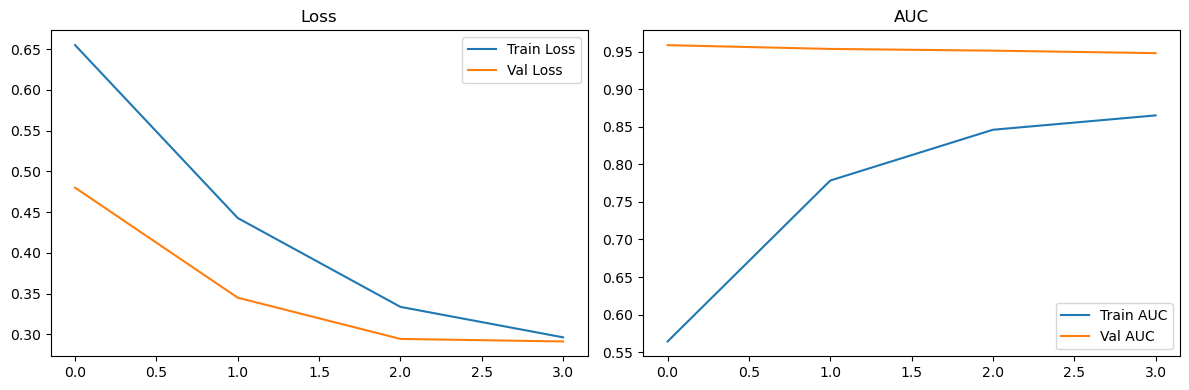

In [22]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["auc"], label="Train AUC")
plt.plot(history.history["val_auc"], label="Val AUC")
plt.title("AUC")
plt.legend()

plt.tight_layout()
plt.show()

# Final Summary

In [23]:
print("=" * 60)
print("AMAZON PRODUCT REVIEWS MODEL SUMMARY")
print("=" * 60)
print("Dataset shape:", df.shape)
print("Users:", n_users)
print("Items:", n_items)
print("Feedback types:")
print(df["feedback_type"].value_counts())
print("\nNoise types:")
print(df["noise_type"].value_counts())
print("\nAttack labels:")
print(df["attack_label"].value_counts())
print("\nFinal Test AUC:", round(auc_score, 4))
print("Normal-only AUC :", round(normal_auc, 4))
print("Attack-only AUC :", round(attack_auc, 4))
print("=" * 60)

AMAZON PRODUCT REVIEWS MODEL SUMMARY
Dataset shape: (1210, 20)
Users: 789
Items: 53
Feedback types:
feedback_type
ep    760
ip    388
en     32
in     30
Name: count, dtype: int64

Noise types:
noise_type
original            850
average_attack      120
bandwagon_attack    120
random_attack       120
Name: count, dtype: int64

Attack labels:
attack_label
0    850
1    360
Name: count, dtype: int64

Final Test AUC: 0.9602
Normal-only AUC : 0.9839
Attack-only AUC : 0.7602


# RMSE & MAE

In [56]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# preds = model.predict(X_test).ravel()
# y_test = true labels

rmse_rmftn = np.sqrt(mean_squared_error(y_test, preds))
mae_rmftn = mean_absolute_error(y_test, preds)

print("RMFTN Probability RMSE:", round(rmse_rmftn, 4))
print("RMFTN Probability MAE :", round(mae_rmftn, 4))

RMFTN Probability RMSE: 0.3834
RMFTN Probability MAE : 0.373
